# 1. EDA & 전처리 파이프라인 구현

In [1]:
# 필요한 툴 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 불러오기
path = '/Users/seoin/Documents/ML_final_project_SeoinBae/diabetes.csv'
df = pd.read_csv(path)

df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [2]:
import platform

# 내 컴퓨터에 맞는 한글 폰트 설정하기
os_name = platform.system()
if os_name == "Windows":
    plt.rcParams['font.family'] = 'Malgun Gothic' # 윈도우
elif os_name == "Darwin":
    plt.rcParams['font.family'] = 'AppleGothic'   # 맥북
else:
    plt.rcParams['font.family'] = 'NanumGothic'   # 기타(코랩 등)

In [3]:
print(df.info())
print('-'* 100)
print(df.isnull().sum())
print('-'* 100)
print(df.shape)

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None
----------------------------------------------------------------------------------------------------
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                  

### 📌 데이터셋 기본 정보

| Column | 한국어 | 의미 |
|---|---|---|
| `Pregnancies` | 임신 횟수 | 환자의 과거 임신 총 횟수 |
| `Glucose` | 포도당 수치 | 경구 포도당 부하 검사 2시간 후의 혈장 포도당 농도 |
| `BloodPressure` | 혈압 | 이완기 혈압 (mm Hg) |
| `SkinThickness` | 피부 두께 | 삼두근 피부 주름 두께 (mm) |
| `Insulin` | 인슐린 수치 | 혈청 인슐린 수치 (mu U/ml) |
| `BMI` | 체질량 지수 | 비만도 지수 (체중 kg / 신장 m²) |
| `DiabetesPedigreeFunction` | 당뇨 내력 가중치 | 가족력 기반 당뇨병 유전 확률 점수 |
| `Age` | 나이 | 환자의 나이 |
| `Outcome` | 당뇨병 여부 | 0 = 음성, 1 = 양성(당뇨병) |

- **총 관측치:** 768개
- **총 특성(컬럼):** 9개
- **데이터 타입:** 정수형(`int64`), 실수형(`float64`)
- **결측치:** 없음

In [4]:
# 모두 숫자형 데이터(정수/실수) 따라서 특별한 전처리 없이 기초 통계치 확인 가능
# 기술통계 + 상관관계 확인
print(df.describe())
print('-'* 100)
print(df.corr())

       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min      0.000000                  

Min/Max 확인
- 임신 횟수 차이 큼. 이상치 의심됨.
- 포도당 수치, 인슐린 수치, 피부 두께, 체질량 수치의 최솟값이 0인데, 결측치 의심됨. (그 외 값들은 0이 가능하다고 판단)

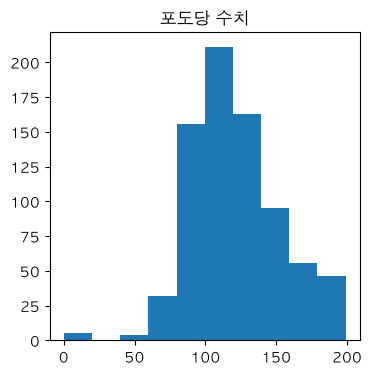

In [5]:
plt.figure(figsize=(4,4))
plt.hist(df['Glucose'], bins=10)
plt.title('포도당 수치')
plt.show()

임의로 포도당 수치만 히스토그램으로 분포 확인
- 그 외 다른 컬럼에 대해서도 mean 과 median의 크기 비교를 통해 간단히 편향된 분포인지, 어느쪽으로 편향되었는지 알 수 있다.

In [6]:
# 0인 값 확인
(df == 0).sum()

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

In [7]:
# 결측치 처리
df[['Glucose','BloodPressure','SkinThickness','Insulin','BMI']] = df[['Glucose','BloodPressure','SkinThickness','Insulin','BMI']].replace(0, np.nan)
df.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [8]:
# 결측치 처리 : 통계적 대푯값 대치
cols = ['Glucose','BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in cols:
    df[col] = df[col].fillna(df[col].median())

df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

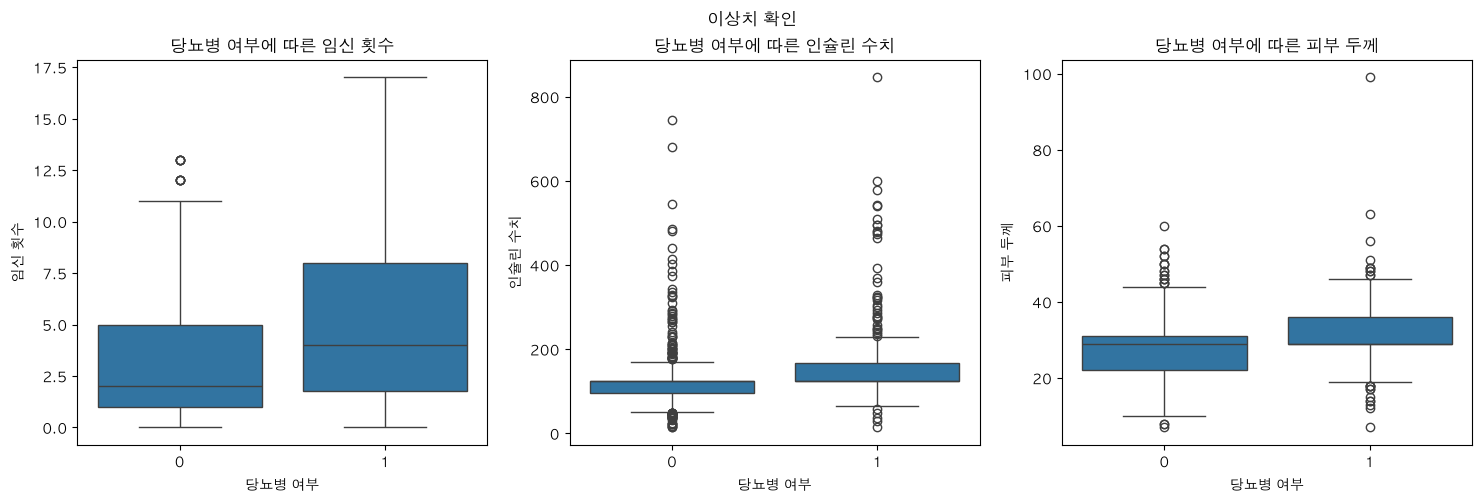

In [14]:
# 박스플롯으로 이상치 확인하기
fig, axes = plt.subplots(1, 3, figsize=(18,5))
fig.suptitle('이상치 확인')

sns.boxplot(x='Outcome', y='Pregnancies', data=df, ax=axes[0])
axes[0].set_title('당뇨병 여부에 따른 임신 횟수')
axes[0].set_xlabel('당뇨병 여부')
axes[0].set_ylabel('임신 횟수')

sns.boxplot(x='Outcome', y='Insulin', data=df, ax=axes[1])
axes[1].set_title('당뇨병 여부에 따른 인슐린 수치')
axes[1].set_xlabel('당뇨병 여부')
axes[1].set_ylabel('인슐린 수치')

sns.boxplot(x='Outcome', y='SkinThickness', data=df, ax=axes[2])
axes[2].set_title('당뇨병 여부에 따른 피부 두께')
axes[2].set_xlabel('당뇨병 여부')
axes[2].set_ylabel('피부 두께')

plt.show()

In [9]:
# 중복 데이터 확인
duplicated_rows = df[df.duplicated(keep=False)] # keep=False는 중복된 모든 행을 표시
duplicated_rows

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome


In [10]:
# 피어슨 상관계수 계산
matrix_cols = [
    'Pregnancies',
    'Glucose',
    'BloodPressure', 
    'SkinThickness', 
    'Insulin', 
    'BMI',
    'DiabetesPedigreeFunction',
    'Age',
    'Outcome'
    ]

corr_matrix = df[matrix_cols].corr(method='pearson')
print(corr_matrix)

                          Pregnancies   Glucose  BloodPressure  SkinThickness  \
Pregnancies                  1.000000  0.128213       0.208615       0.081770   
Glucose                      0.128213  1.000000       0.218937       0.192615   
BloodPressure                0.208615  0.218937       1.000000       0.191892   
SkinThickness                0.081770  0.192615       0.191892       1.000000   
Insulin                      0.025047  0.419451       0.045363       0.155610   
BMI                          0.021559  0.231049       0.281257       0.543205   
DiabetesPedigreeFunction    -0.033523  0.137327      -0.002378       0.102188   
Age                          0.544341  0.266909       0.324915       0.126107   
Outcome                      0.221898  0.492782       0.165723       0.214873   

                           Insulin       BMI  DiabetesPedigreeFunction  \
Pregnancies               0.025047  0.021559                 -0.033523   
Glucose                   0.419451  0.231

In [ ]:
# 종속변수와 상관이 높은 순으로 정렬
corr_matrix['Outcome'].sort_values(ascending=False)

Outcome                     1.000000
Glucose                     0.492782
BMI                         0.312038
Age                         0.238356
Pregnancies                 0.221898
SkinThickness               0.214873
Insulin                     0.203790
DiabetesPedigreeFunction    0.173844
BloodPressure               0.165723
Name: Outcome, dtype: float64

In [21]:
# 피어슨 상관계수 계산

features = [
    'Outcome',
    'Glucose',
    'BMI',
    'Age',
    'Pregnancies',
    'DiabetesPedigreeFunction'
]

# 해당 컬럼만 선택한 df 생성
matrix_df = df[features].dropna()

# 피어슨 상관행렬 계산
corr_matrix = matrix_df.corr(method='pearson')

print("---------- [ 피어슨 상관행렬 ] ----------")
print(corr_matrix)

---------- [ 피어슨 상관행렬 ] ----------
                           Outcome   Glucose       BMI       Age  Pregnancies  \
Outcome                   1.000000  0.492782  0.312038  0.238356     0.221898   
Glucose                   0.492782  1.000000  0.231049  0.266909     0.128213   
BMI                       0.312038  0.231049  1.000000  0.025597     0.021559   
Age                       0.238356  0.266909  0.025597  1.000000     0.544341   
Pregnancies               0.221898  0.128213  0.021559  0.544341     1.000000   
DiabetesPedigreeFunction  0.173844  0.137327  0.153438  0.033561    -0.033523   

                          DiabetesPedigreeFunction  
Outcome                                   0.173844  
Glucose                                   0.137327  
BMI                                       0.153438  
Age                                       0.033561  
Pregnancies                              -0.033523  
DiabetesPedigreeFunction                  1.000000  


/var/folders/my/m47hbmtd7235qxgskqcmv3mw0000gn/T/ipykernel_31851/880478748.py:14: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) AppleGothic.
  plt.tight_layout()
/Users/seoin/Documents/ML_final_project_SeoinBae/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)


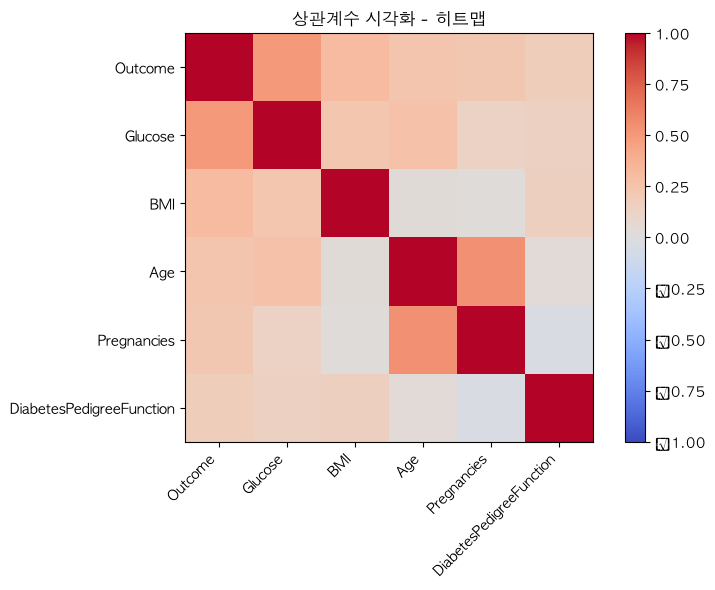

In [26]:
# 히트맵 (시각화)
fig, ax = plt.subplots(figsize=(8,6))
im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1,vmax=1)

ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))

ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right')
ax.set_yticklabels(corr_matrix.columns)

fig.colorbar(im)

plt.title('상관계수 시각화 - 히트맵')
plt.tight_layout()
plt.show()

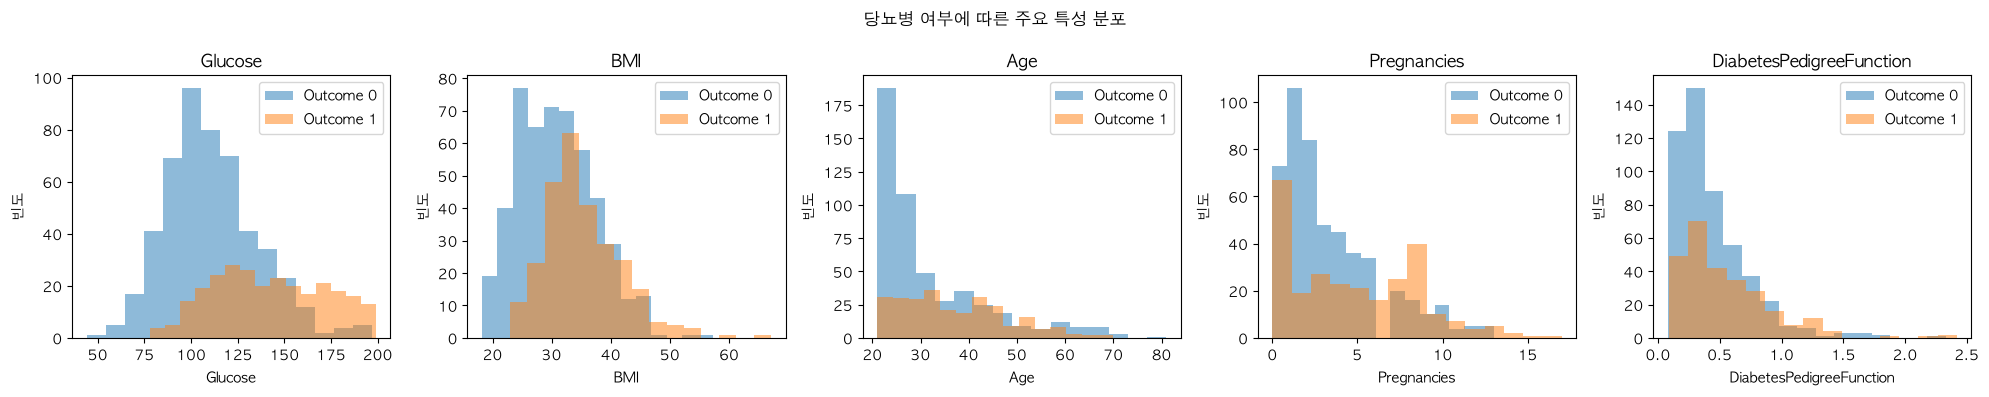

In [29]:
# 주요 변수
from numpy import positive


features = [
    'Glucose',
    'BMI',
    'Age',
    'Pregnancies',
    'DiabetesPedigreeFunction'
]

# 주요 변수 히스토그램 (두 그룹으로 분류)
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle('당뇨병 여부에 따른 주요 특성 분포')

for i, col in enumerate(features):
    
    negative = df[df['Outcome']==0][col]
    positive = df[df['Outcome']==1][col]
    
    axes[i].hist(negative, bins=15, alpha=0.5, label='Outcome 0')
    axes[i].hist(positive, bins=15, alpha=0.5, label='Outcome 1')

    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('빈도')
    axes[i].legend()

plt.tight_layout()
plt.show()


## 지금 시각화 검토

**전체적으로 잘 나왔고, 이 그림은 최종 과제에 넣어도 돼.** 특히 그냥 변수별 Histogram을 그린 것보다 `Outcome 0/1`을 겹쳐 놓아서 훨씬 분석할 내용이 많아졌어.

그림에서 실제로 보이는 특징을 변수별로 보면:

- **Glucose:** 가장 뚜렷해. Outcome 0은 대체로 낮은 Glucose 영역에 집중되어 있고, Outcome 1은 상대적으로 오른쪽의 높은 값까지 넓게 분포해. 앞서 나온 `Outcome과 r≈0.493`이라는 결과와도 방향이 일치해.
- **BMI:** Outcome 1의 분포가 Outcome 0보다 상대적으로 높은 BMI 영역으로 이동해 있는 모습이 보이지만 두 집단의 겹침도 상당해. `r≈0.312`였던 것과도 자연스럽게 연결 가능.
- **Age:** 두 집단 모두 젊은 연령대에 많이 몰려 있지만 Outcome 1이 상대적으로 높은 연령까지 더 넓게 분포하는 모습이 보여.
- **Pregnancies:** 두 집단 모두 낮은 임신 횟수에 많이 분포하지만 Outcome 1은 상대적으로 높은 임신 횟수 영역에도 관측치가 나타나. 다만 겹침이 상당히 커.
- **DiabetesPedigreeFunction:** 둘 다 낮은 값에 집중되고 오른쪽으로 긴 꼬리를 가진 **right-skewed 분포**가 확실히 보여. 두 그룹 간 분포 차이는 Glucose만큼 뚜렷하지 않아. 앞서 낮았던 `r≈0.174`와도 연결해서 설명할 수 있고.

그래서 Markdown 분석은 이 정도면 좋아:

```markdown
### 주요 변수 분포 시각화 분석

Outcome을 기준으로 당뇨병 음성(0)과 양성(1) 집단을 구분하여 주요 변수의 분포를 비교하였다.

Glucose는 두 집단 간 분포 차이가 가장 뚜렷하게 나타났으며, 당뇨병 양성 집단이 상대적으로 높은 Glucose 값에 분포하는 경향을 보였다. 이는 Pearson 상관분석에서 Glucose가 Outcome과 가장 높은 양의 상관관계(r≈0.493)를 보인 결과와도 일치한다.

BMI와 Age 역시 양성 집단이 상대적으로 높은 값까지 분포하는 경향이 나타났으나 두 집단의 분포가 상당 부분 겹쳤다. Pregnancies에서도 양성 집단이 비교적 높은 임신 횟수까지 분포하는 모습을 확인할 수 있었다.

DiabetesPedigreeFunction은 두 집단 모두 낮은 값에 관측치가 집중되고 높은 값 방향으로 긴 꼬리를 가지는 우측 편향 분포를 보였으며, 두 집단 간 분포 차이는 상대적으로 크지 않았다.

따라서 주요 변수 중 Glucose에서 당뇨병 여부에 따른 분포 차이가 가장 뚜렷하게 관찰되었으며, 다른 변수들은 두 집단 사이에 상당한 분포 중첩이 존재하였다.

## [문항 1-2] 전처리 방법 선택 근거

### 1. 생리학적으로 의미가 없는 0 값 처리

초기 데이터 구조를 확인한 결과 `info()`와 `isnull().sum()`에서는 결측값이 발견되지 않았다. 그러나 `describe()`와 각 변수의 0 값 개수를 추가로 확인한 결과, Glucose, BloodPressure, SkinThickness, Insulin, BMI와 같이 실제 측정값으로 0이 나타나기 어려운 변수에 0이 포함되어 있었다.

따라서 해당 변수의 0 값을 실제 관측값이 아닌 결측값으로 판단하여 `NaN`으로 변환하였다.

반면 Pregnancies의 0은 임신 경험이 없음을 의미할 수 있으며, Outcome의 0은 당뇨병 음성 클래스를 의미하므로 결측값으로 처리하지 않았다.

### 2. 결측값 대체 방법 선정

0 값을 NaN으로 변환한 후 변수별 결측값을 확인하였다.

현재 데이터는 각 행이 서로 독립적인 관측 대상에 해당하므로 시간적 순서가 중요한 시계열 데이터가 아니다. 따라서 이전 또는 다음 관측값을 이용하는 `ffill`, `bfill`이나 관측값 사이의 연속적인 변화를 가정하는 선형 보간법은 적절하지 않다고 판단하였다.

또한 일부 변수의 Histogram과 Boxplot에서 치우친 분포와 이상치 후보가 확인되었다. 평균은 이러한 극단값의 영향을 받을 수 있기 때문에, 상대적으로 이상치의 영향을 적게 받는 중앙값(Median)을 각 변수의 대표값으로 사용하여 결측값을 대치하였다.

### 3. 이상치 처리

Boxplot을 통해 일부 변수에서 IQR 범위를 벗어나는 이상치 후보를 확인하였다.

그러나 통계적인 이상치가 반드시 잘못 입력된 데이터라는 것을 의미하지 않으며, 해당 값들이 실제 관측 가능한 값일 가능성을 배제하기 어려웠다. 따라서 임의의 기준으로 데이터를 삭제할 경우 유효한 정보가 손실될 수 있다고 판단하여 별도의 이상치 제거를 수행하지 않고 분석에 포함하였다.

### 4. 범주형 변수 인코딩

종속변수인 Outcome은 당뇨병 여부를 나타내는 범주형 변수이지만 이미 0과 1의 숫자 형태로 표현되어 있다. 또한 나머지 독립변수도 모두 수치형 변수이므로 별도의 Label Encoding 또는 One-Hot Encoding은 적용하지 않았다.

### 5. 데이터 스케일링

각 독립변수는 서로 다른 단위와 값의 범위를 가지고 있으므로,
모델 학습 과정에서 변수 간 척도의 차이를 조정하기 위해
StandardScaler를 적용하였다.

StandardScaler는 각 특성을 평균 0, 표준편차 1을 기준으로
표준화하며, 본 과제에서 사용할 분류 모델의 안정적인 학습과
규제 적용을 위해 선택하였다.

또한 데이터 누수를 방지하기 위해 학습 데이터에 대해서만
Scaler를 fit하고, 학습 데이터와 테스트 데이터에는 동일한
Scaler를 이용하여 transform하였다.

# 2. 머신러닝 모델 학습, 과적합 점검 및 하이퍼파라미터 튜닝

In [ ]:
# 필요한 툴 불러오기


In [ ]:
# 로지스틱 회귀 분류 모델 + 오차 평가 지표


In [ ]:
# 규제

In [ ]:
# 교차 검증

In [ ]:
# 하이퍼파라미터 튜닝

# 3. Hugging Face 사전 학습된 모델을 활용한 뉴스 기사 분류 및 추론

In [ ]:
# Gemma & 토그나이저 독립된 개발 환경 내에 로드

In [ ]:
# 뉴스 기사 텍스트를 분류하기 위해, 프롬프트 내에 정답 카테고리 예시들을 제공하는 Few-shot 프롬프트 구조(문맥 내 학습)를 설계합니다. 별도의 가중치 파인튜닝 없이 사전 학습된 가중치 그대로 뉴스 기사 텍스트를 입력하여 카테고리 추론(Inference) 결과를 도출합니다.

In [ ]:
# [문항 3-3] Generation 하이퍼파라미터 변경 실험 및 성능 비교 해석